# HDT 3: Inferencia, Naive Bayes y Regresión

**Ciencia de Datos, Sección A** · Asignada: jueves 20 de agosto · **Entrega: jueves 27 de agosto, 23:59**

**Nombre:** Ana Sofía Eggenberger

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib seaborn scikit-learn`. Todo es determinista (semillas fijas y datasets estáticos): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Parte A · Inferencia y A/B testing (0.5 pt)

El experimento del botón, en grande: 50,000 visitantes por grupo. La tasa real del control es 10.0% y la de la variante 10.5%: un efecto **pequeño** con una muestra **enorme**. Ese contraste es el tema de la parte D.

### Ejercicio 1 (0.15): la diferencia y su intervalo

(a) La diferencia observada `obs` entre variante y control. (b) El error estándar de la diferencia: $\sqrt{s_a^2/n + s_b^2/n}$ con `var(ddof=1)`. (c) El intervalo del 95%: `obs` ± 1.96 × SE. ¿El intervalo incluye el cero?

In [2]:
rng = np.random.default_rng(9)
n_ab = 50_000
control = rng.binomial(1, 0.100, n_ab)
variante = rng.binomial(1, 0.105, n_ab)

obs = variante.mean() - control.mean()

se = np.sqrt(
    control.var(ddof=1) / n_ab +
    variante.var(ddof=1) / n_ab
)

intervalo = (obs - 1.96 * se, obs + 1.96 * se)

# imprimir el intervalo
print("Diferencia observada:", obs)
print("Error estándar:", se)
print("Intervalo del 95%:", intervalo)
print("¿Incluye cero?", intervalo[0] <= 0 <= intervalo[1])

# Verificación (descomentar):
assert round(obs, 5) == 0.00506
assert round(obs - 1.96 * se, 5) == 0.00132

Diferencia observada: 0.005059999999999995
Error estándar: 0.0019083155277267612
Intervalo del 95%: (np.float64(0.0013197015656555432), np.float64(0.008800298434344447))
¿Incluye cero? False


### Ejercicio 2 (0.20): test de permutación desde cero

Si el botón no importara, las etiquetas serían intercambiables. Completar la función: concatenar, revolver `reps` veces, partir en dos grupos del tamaño original, guardar la diferencia, y devolver la fracción de diferencias tan extremas como la observada.

In [3]:
def test_permutacion(a, b, reps=3000, seed=1):
    rng_p = np.random.default_rng(seed)
    obs_ = b.mean() - a.mean()

    # Juntar los dos grupos
    todos = np.concatenate([a, b])

    # Guardar las diferencias de cada permutación
    diferencias = np.empty(reps)

    for i in range(reps):
        rng_p.shuffle(todos)

        grupo_a = todos[:len(a)]
        grupo_b = todos[len(a):]

        diferencias[i] = grupo_b.mean() - grupo_a.mean()

    # Proporción de diferencias tan extremas como la observada
    return np.mean(np.abs(diferencias) >= np.abs(obs_))


p_val = test_permutacion(control, variante)

print("p-value:", p_val)

# Verificación (descomentar):
assert round(p_val, 3) == 0.008

p-value: 0.008


### Ejercicio 3 (0.15): 100 tests bajo $H_0$

Ningún efecto existe: los dos grupos vienen de la misma Normal. Contar cuántos "descubrimientos" aparecen con $\alpha = 0.05$ (umbral 1.96) y cuántos sobreviven Bonferroni ($\alpha/100$, umbral 3.48).

In [4]:
def z(a_, b_):
    s = np.sqrt(a_.var()/len(a_) + b_.var()/len(b_))
    return (b_.mean() - a_.mean()) / s

rng3 = np.random.default_rng(2)
significativos = 0
significativos_bonf = 0

for i in range(100):
    g1 = rng3.normal(0, 1, 500)
    g2 = rng3.normal(0, 1, 500)

    z_val = z(g1, g2)

    if abs(z_val) > 1.96:
        significativos += 1

    if abs(z_val) > 3.48:
        significativos_bonf += 1

print("Significativos con alpha = 0.05:", significativos)
print("Significativos con Bonferroni:", significativos_bonf)

# Verificación (descomentar):
assert significativos == 3 and significativos_bonf == 0

Significativos con alpha = 0.05: 3
Significativos con Bonferroni: 0


## Parte B · Naive Bayes (0.5 pt)

Un filtro de spam para mensajes de texto, desde cero, como en la sesión 7. El corpus:

In [5]:
textos = [
    "gana un premio reclamalo hoy mismo",
    "oferta exclusiva solo por hoy haz clic",
    "felicidades fuiste seleccionado para un premio",
    "crédito preaprobado sin requisitos aplica ya",
    "última oportunidad descuento del 90 por ciento",
    "tu cuenta será suspendida verifica tus datos",
    "recarga doble gratis si respondes ya",
    "has ganado un viaje reclama tu premio aquí",
    "nos vemos a las 8 en la u",
    "ya voy en camino llego en 10",
    "mamá dice que compres tortillas",
    "el partido quedó 2 a 1 increíble",
    "te mando el resumen de la clase en la noche",
    "feliz cumple nos vemos el sábado",
    "se me olvidó la usb me la prestas",
    "la tarea es para el martes no para hoy",
]

etiquetas = ["spam"] * 8 + ["normal"] * 8

test_x = [
    "reclama tu premio gratis haz clic ya",
    "llego en 5 nos vemos en la entrada",
    "oferta solo hoy tu crédito ya está aprobado",
    "la clase se movió para el jueves",
]
test_y = ["spam", "normal", "spam", "normal"]

print(len(textos), len(etiquetas), len(test_x))

16 16 4


### Ejercicio 4 (0.15): bolsa de palabras

(a) `vocab`: la lista **ordenada** de palabras únicas del corpus de entrenamiento. (b) `idx`: diccionario palabra → posición. (c) `conteos` (matriz clases × |V|) y `priors`, contando sobre `textos`.

In [6]:
def tokenizar(texto):
    return texto.lower().split()

clases = sorted(set(etiquetas))   # ["normal", "spam"]

# Crear vocabulario ordenado con todas las palabras únicas
vocab = sorted(set(
    palabra
    for texto in textos
    for palabra in tokenizar(texto)
))

# Diccionario palabra -> posición
idx = {palabra: i for i, palabra in enumerate(vocab)}

# Matriz de conteos: filas = clases, columnas = palabras
conteos = np.zeros((len(clases), len(vocab)))

# Cantidad de mensajes de cada clase
priors = np.zeros(len(clases))

for texto, etiqueta in zip(textos, etiquetas):
    clase_i = clases.index(etiqueta)
    priors[clase_i] += 1

    for palabra in tokenizar(texto):
        conteos[clase_i, idx[palabra]] += 1

print("Tamaño del vocabulario:", len(vocab))
print("Forma de conteos:", conteos.shape)
print("Priors:", priors)

# Verificación (descomentar):
assert len(vocab) == 86
assert conteos.shape == (2, 86)
assert priors.tolist() == [8.0, 8.0]

Tamaño del vocabulario: 86
Forma de conteos: (2, 86)
Priors: [8. 8.]


### Ejercicio 5 (0.20): entrenar con Laplace y clasificar

(a) Suavizar: `conteos + 1`. (b) `log_veros` (normalizar por fila y tomar log) y `log_prior`. (c) `puntajes(texto)` que suma log-prior más log-verosimilitud de cada palabra **conocida**, y `predecir(texto)` con el argmax. (d) Clasificar los 4 mensajes de prueba.

In [7]:
# Suavizado de Laplace
suavizados = conteos + 1

# Log-verosimilitudes por clase
log_veros = np.log(
    suavizados / suavizados.sum(axis=1, keepdims=True)
)

# Log-prior de cada clase
log_prior = np.log(priors / priors.sum())


def puntajes(texto):
    scores = log_prior.copy()

    for palabra in tokenizar(texto):
        if palabra in idx:
            scores += log_veros[:, idx[palabra]]

    return scores


def predecir(texto):
    scores = puntajes(texto)
    return clases[np.argmax(scores)]


predicciones = [predecir(t) for t in test_x]

print("Predicciones:", predicciones)
print("Reales:      ", test_y)

# Verificación (descomentar):
assert [predecir(t) for t in test_x] == test_y

Predicciones: ['spam', 'normal', 'spam', 'normal']
Reales:       ['spam', 'normal', 'spam', 'normal']


### Ejercicio 6 (0.15): las palabras que delatan al spam

`ratio` = log-verosimilitud de spam menos la de normal. Con `np.argsort`, extraer las 5 palabras más spam (`informativas_spam`) y las 5 más normales (`informativas_normal`).

In [8]:
# Ratio: spam menos normal
ratio = log_veros[1] - log_veros[0]

# Diccionario posición -> palabra
inv = {i: w for w, i in idx.items()}

# Ordenar directamente de mayor a menor para spam
orden_spam = np.argsort(-ratio)

# Ordenar de menor a mayor para normal
orden_normal = np.argsort(ratio)

# 5 palabras más informativas de cada clase
informativas_spam = [inv[i] for i in orden_spam[:5]]
informativas_normal = [inv[i] for i in orden_normal[:5]]

print("Más spam:", informativas_spam)
print("Más normal:", informativas_normal)

# Verificación (descomentar):
assert informativas_spam[0] == "premio"

Más spam: ['premio', 'un', 'tu', 'por', 'crédito']
Más normal: ['la', 'en', 'el', 'a', 'me']


## Parte C · Regresión lineal (0.8 pt)

`diamonds`: 53,940 diamantes reales. La pregunta de negocio: ¿cuánto vale un quilate?

### Ejercicio 7 (0.20): EDA mínimo

(a) `shape` y `dtypes`. (b) Media y mediana de `price`: ¿cuál es mayor y qué dice eso de la cola? (c) El histograma de `price`.

Shape: (53940, 10)

Tipos de datos:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Media de price: 3932.799721913237
Mediana de price: 2401.0
La media es mayor que la mediana: la distribución tiene cola hacia la derecha.


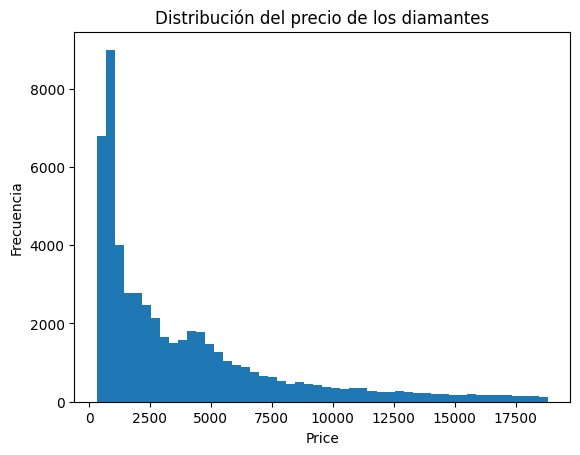

In [9]:
diamonds = sns.load_dataset("diamonds")

# Tamaño y tipos de datos
print("Shape:", diamonds.shape)
print("\nTipos de datos:")
print(diamonds.dtypes)

# Media y mediana de price
media_price = diamonds["price"].mean()
mediana_price = diamonds["price"].median()

print("\nMedia de price:", media_price)
print("Mediana de price:", mediana_price)

if media_price > mediana_price:
    print("La media es mayor que la mediana: la distribución tiene cola hacia la derecha.")
else:
    print("La mediana es mayor o igual que la media.")

# Histograma de price
plt.hist(diamonds["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio de los diamantes")
plt.show()

# Verificación (descomentar):
assert diamonds.shape == (53940, 10)
assert diamonds["price"].median() == 2401.0

### Ejercicio 8 (0.20): OLS a mano

`price ~ carat` con las ecuaciones normales: (a) `Xb` con columna de unos y `np.linalg.solve`. (b) $R^2$ a mano (`r2_precio`). (c) Comparar contra `LinearRegression`.

In [10]:
from sklearn.linear_model import LinearRegression

x_c = diamonds["carat"].to_numpy(float)
y_p = diamonds["price"].to_numpy(float)

# Matriz de diseño: columna de unos + carat
Xb = np.column_stack((np.ones(len(x_c)), x_c))

# Ecuaciones normales usando np.linalg.solve
beta = np.linalg.solve(Xb.T @ Xb, Xb.T @ y_p)

# Predicciones
y_hat = Xb @ beta

# R^2 a mano
ss_res = np.sum((y_p - y_hat) ** 2)
ss_tot = np.sum((y_p - y_p.mean()) ** 2)
r2_precio = 1 - ss_res / ss_tot

print("Intercepto:", beta[0])
print("Pendiente:", beta[1])
print("R^2 a mano:", r2_precio)

# Comparación con sklearn
modelo = LinearRegression()
modelo.fit(x_c.reshape(-1, 1), y_p)

print("\nLinearRegression:")
print("Intercepto:", modelo.intercept_)
print("Pendiente:", modelo.coef_[0])
print("R^2:", modelo.score(x_c.reshape(-1, 1), y_p))

# Verificación (descomentar):
assert round(r2_precio, 3) == 0.849

Intercepto: -2256.3605800455207
Pendiente: 7756.425617968583
R^2 a mano: 0.8493305264354858

LinearRegression:
Intercepto: -2256.360580045403
Pendiente: 7756.425617968435
R^2: 0.8493305264354858


### Ejercicio 9 (0.20): los residuos delatan, el log arregla

(a) Graficar residuos vs predicción del modelo del ejercicio 8. (b) Ajustar `log(price) ~ log(carat)` (`r2_log`) y graficar sus residuos. (c) Comparar los dos $R^2$ y las dos nubes.

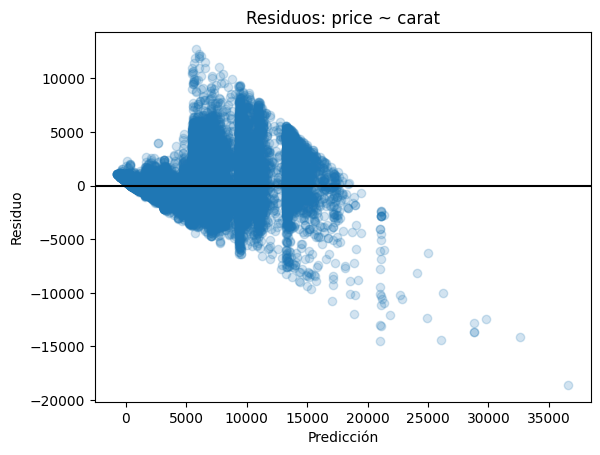

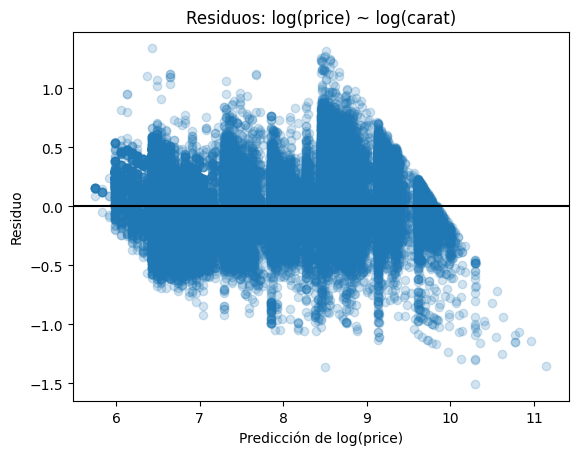

R^2 price ~ carat: 0.8493305264354858
R^2 log(price) ~ log(carat): 0.9329893079520857


In [11]:
# Residuos del modelo original price ~ carat
residuos = y_p - y_hat

plt.scatter(y_hat, residuos, alpha=0.2)
plt.axhline(0, color="black")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos: price ~ carat")
plt.show()


# Modelo log(price) ~ log(carat)
log_x = np.log(x_c)
log_y = np.log(y_p)

modelo_log = LinearRegression()
modelo_log.fit(log_x.reshape(-1, 1), log_y)

log_y_hat = modelo_log.predict(log_x.reshape(-1, 1))

# R^2 del modelo log-log
ss_res_log = np.sum((log_y - log_y_hat) ** 2)
ss_tot_log = np.sum((log_y - log_y.mean()) ** 2)
r2_log = 1 - ss_res_log / ss_tot_log

# Residuos del modelo log-log
residuos_log = log_y - log_y_hat

plt.scatter(log_y_hat, residuos_log, alpha=0.2)
plt.axhline(0, color="black")
plt.xlabel("Predicción de log(price)")
plt.ylabel("Residuo")
plt.title("Residuos: log(price) ~ log(carat)")
plt.show()

print("R^2 price ~ carat:", r2_precio)
print("R^2 log(price) ~ log(carat):", r2_log)

# Verificación (descomentar):
assert round(r2_log, 3) == 0.933

### Ejercicio 10 (0.20): ¿y si agregamos más features?

Regresión múltiple en la escala log: `log(price) ~ log(carat) + depth + table`. Calcular `r2_multi` y responder en un comentario: ¿cuánto mejoró respecto al ejercicio 9?

In [12]:
# Variables para la regresión múltiple
X_multi = np.column_stack((
    np.log(diamonds["carat"].to_numpy(float)),
    diamonds["depth"].to_numpy(float),
    diamonds["table"].to_numpy(float)
))

y_multi = np.log(diamonds["price"].to_numpy(float))

# Ajustar modelo
modelo_multi = LinearRegression()
modelo_multi.fit(X_multi, y_multi)

# R^2
r2_multi = modelo_multi.score(X_multi, y_multi)

print("R^2 modelo log-log:", r2_log)
print("R^2 modelo múltiple:", r2_multi)
print("Mejora:", r2_multi - r2_log)

# Agregar depth y table mejora muy poco el modelo:
# el R^2 aumenta aproximadamente de 0.933 a 0.935,
# es decir, cerca de 0.002 (0.2 puntos porcentuales).

# Verificación (descomentar):
assert round(r2_multi, 3) == 0.935

R^2 modelo log-log: 0.9329893079520857
R^2 modelo múltiple: 0.9352584483430644
Mejora: 0.0022691403909786967


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** El ejercicio 2 dio p = 0.008: el efecto del botón es estadísticamente real. El lift observado fue de medio punto porcentual (10.4% vs 9.9%). ¿Basta eso para lanzar el botón a producción? ¿Qué información falta para decidir?

**(b)** El modelo log-log del ejercicio 9 se ajustó con diamantes de hasta 5 quilates. ¿Por qué no es confiable usarlo para tasar un diamante de 8 quilates, aunque la fórmula produzca un número?

_(Responder editando esta celda)_

**Respuesta (a):** No necesariamente. Aunque el resultado sí es significativo (p = 0.008), el cambio fue pequeño, de 9.9% a 10.4%. Antes de lanzarlo habría que saber si ese aumento realmente genera suficientes beneficios para justificar el costo de hacer el cambio.

**Respuesta (b):** El modelo tuvo un buen ajuste (R² = 0.933), pero solo se creó usando diamantes de hasta 5 quilates. Predecir el precio de uno de 8 quilates no sería muy confiable porque estaríamos usando el modelo fuera del rango de datos con el que aprendió.

## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- Utilicé AI como herramienta de apoyo durante la hoja de trabajo. Principalmente la usé para entender mejor conceptos que todavía me cuestan, como los tests de permutación, Naive Bayes y la interpretación de los modelos de regresión. También la usé para simplificar y automatizar partes del código que no tenía sentido hacer manualmente. Intenté entender qué hacía cada paso y no solo copiar resultados. Considero que aprender a usar IA de forma responsable también es útil para resolver este tipo de problemas de manera más eficiente.